
# Lab 1

## Task 1: Load and inspect the housing data

In [ ]:
import pandas as pd
File_Path= "/content/housing.csv"
housing= pd.read_csv(File_Path)
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Task 2: Explore the dataset to answer the research questions

Q1. How many geographical units are there in the dataset?


In [ ]:
total_units=len(housing)
print(f"Total Units: {total_units}")

number_of_unique_geo_units= housing[['longitude','latitude']].drop_duplicates().shape[0]
display(f"Total number of unique geographical units: {number_of_unique_geo_units}")



Total Units: 20640


'Total number of unique geographical units: 12590'

Q2. What is the mean house value among all “Ocean_proximity” categories?

In [ ]:
overall_mean = housing['median_house_value'].mean().round(0)
print(f"Overall mean house value: {overall_mean}")

Overall mean house value: 206856.0


Q3. What is the mean house value in each “Ocean_proximity” category?

In [ ]:
mean_house_value_by_Ocean_category = housing.groupby('ocean_proximity')['median_house_value'].mean()
mean_house_value_by_Ocean_category.name='Mean_house_value_by_Ocean_Proximity'
mean_house_value_by_Ocean_category


,Mean_house_value_by_Ocean_Proximity
ocean_proximity,
<1H OCEAN,240084.285464
INLAND,124805.392001
ISLAND,380440.000000
NEAR BAY,259212.311790
NEAR OCEAN,249433.977427


In [ ]:
median_house_value_by_Ocean_category=housing.groupby('ocean_proximity')['median_house_value'].median()
median_house_value_by_Ocean_category.name='Median_house_value_by_Ocean_Proximity '
median_house_value_by_Ocean_category

,Median_house_value_by_Ocean_Proximity
ocean_proximity,
<1H OCEAN,214850.0
INLAND,108500.0
ISLAND,414700.0
NEAR BAY,233800.0
NEAR OCEAN,229450.0


Q4. What can you tell about the differences between the mean and median values
“Ocean_proximity” categories?

In [ ]:
ocean_value_comparison = housing.groupby('ocean_proximity')['median_house_value'].agg(Mean='mean', Median='median')

ocean_value_comparison['difference'] = ocean_value_comparison['Mean'] - ocean_value_comparison['Median']
print("Mean minus Median Values by Ocean Proximity:\nAs you can see the mean in all ocean categories (except Island category) is bigger than the median.\nA mean higher than median shows that distribution is pulled by high value properties, maybe there are some outliers that pull it up. \nRegarding the (Island) category, a mean lower than the median indicates that the distribution is pulled by lower priced properties.")

ocean_value_comparison

Mean minus Median Values by Ocean Proximity:
As you can see the mean in all ocean categories (except Island category) is bigger than the median.
A mean higher than median shows that distribution is pulled by high value properties, maybe there are some outliers that pull it up. 
Regarding the (Island) category, a mean lower than the median indicates that the distribution is pulled by lower priced properties.


,Mean,Median,difference
ocean_proximity,,,
<1H OCEAN,240084.285464,214850.0,25234.285464
INLAND,124805.392001,108500.0,16305.392001
ISLAND,380440.000000,414700.0,-34260.000000
NEAR BAY,259212.311790,233800.0,25412.311790
NEAR OCEAN,249433.977427,229450.0,19983.977427


Q5. Create a histogram for “households”,“median_income”,“median_house_value”.

Maximum Housing Median Age: 52.0
Minimum Housing Median Age: 1.0
Maximum Median House Value: $500,001.00
Minimum Median House Value: $14,999.00


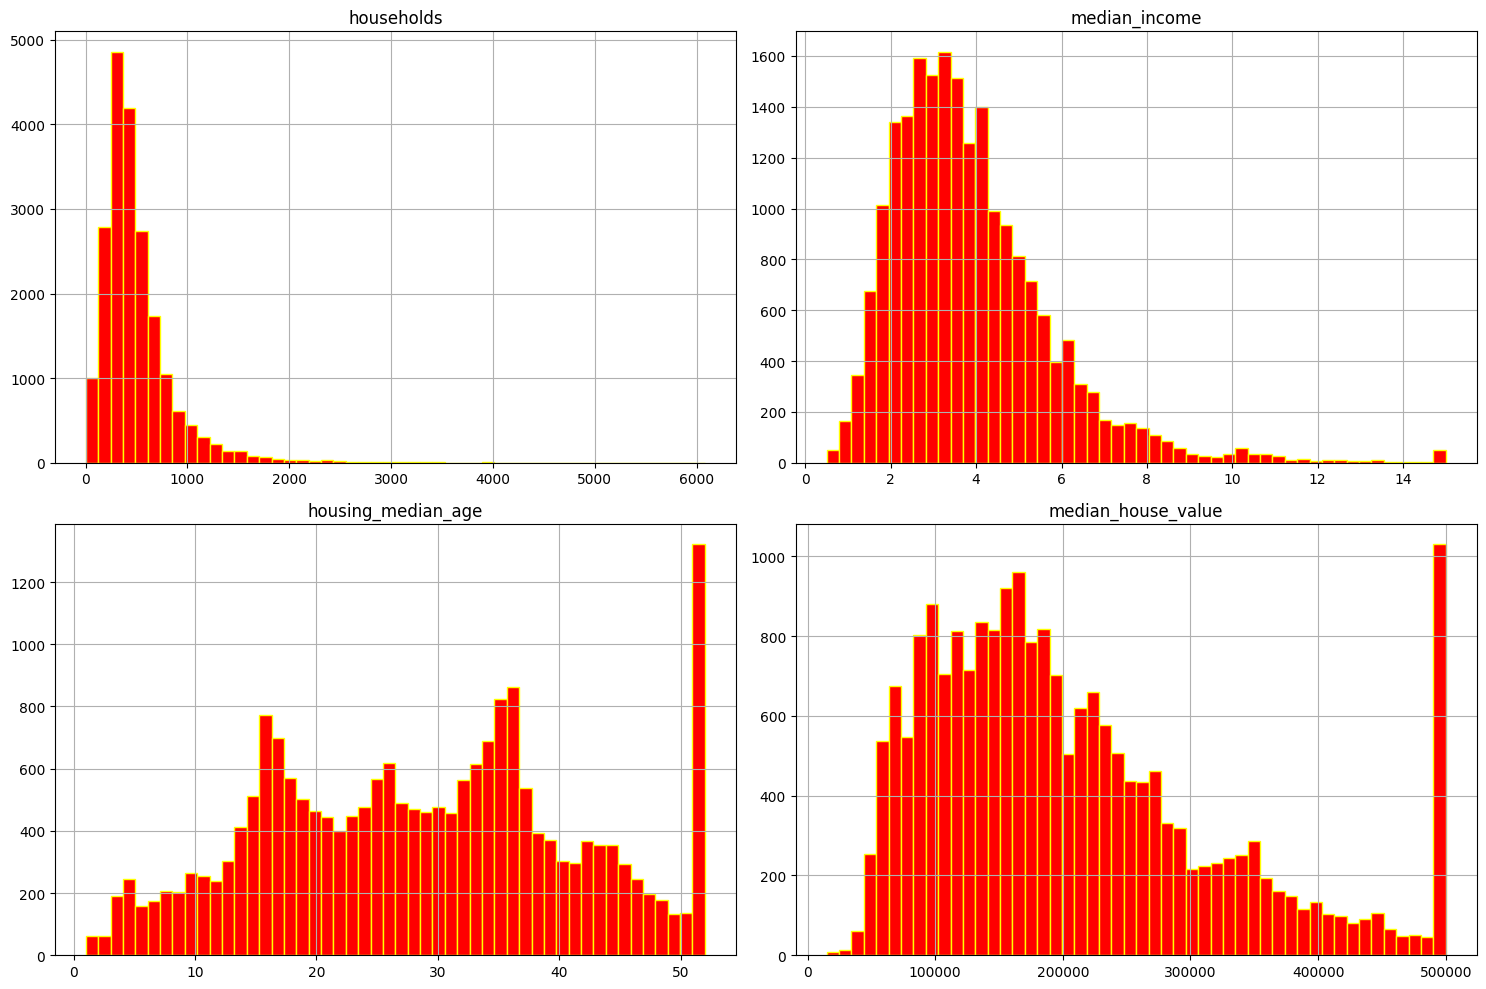

In [ ]:
import matplotlib.pyplot as plt

columns = ["households", "median_income", "housing_median_age", "median_house_value"]

housing[columns].hist(bins=50, figsize=(15, 10), color="red", edgecolor="yellow")

max_housing_median_age = housing['housing_median_age'].max()
min_housing_median_age = housing['housing_median_age'].min()
max_median_house_value = housing['median_house_value'].max()
min_median_house_value = housing['median_house_value'].min()

print(f"Maximum Housing Median Age: {max_housing_median_age}")
print(f"Minimum Housing Median Age: {min_housing_median_age}")
print(f"Maximum Median House Value: ${max_median_house_value:,.2f}")
print(f"Minimum Median House Value: ${min_median_house_value:,.2f}")

plt.tight_layout()
plt.show()

Q6. What do you notice about the graphs? Specifically focus on end of “housing_median_age” and “median_house_value graphs”. What do you think about the magnitude of the values in “median_house_value”?

* We noticed that every house median age value equal or above 52 years was capped also every median house valued at or above $500,000 was capped as we can see in those spiked bins in the graphs. Regarding the magnitude, “median_house_value” has a wide numerical range aprox ( 15,000 - 500,000 ) that needs to be scaled or it will affect the ability to accurately predict values above that range.


Q7. In which category are the most expensive and the largest houses typically located? In which category are the least expensive and smallest houses typically located?

In [ ]:

category_stats = housing.groupby('ocean_proximity')[['median_house_value', 'total_rooms']].mean()
print("Most expensive to least expensive:\n", category_stats.sort_values(by='median_house_value', ascending=False))
print("\nLargest to smallest house:\n", category_stats.sort_values(by='total_rooms', ascending=False))

Most expensive to least expensive:
                  median_house_value  total_rooms
ocean_proximity                                 
ISLAND                380440.000000  1574.600000
NEAR BAY              259212.311790  2493.589520
NEAR OCEAN            249433.977427  2583.700903
<1H OCEAN             240084.285464  2628.343586
INLAND                124805.392001  2717.742787

Largest to smallest house:
                  median_house_value  total_rooms
ocean_proximity                                 
INLAND                124805.392001  2717.742787
<1H OCEAN             240084.285464  2628.343586
NEAR OCEAN            249433.977427  2583.700903
NEAR BAY              259212.311790  2493.589520
ISLAND                380440.000000  1574.600000


Q8.What can you tell about the quality of houses in each “Ocean_proximity” category? (e.g., the age
of the houses, the number of rooms)

In [ ]:

quality_stats = housing.groupby('ocean_proximity')[['housing_median_age', 'total_rooms']].mean()
print(quality_stats)

                 housing_median_age  total_rooms
ocean_proximity                                 
<1H OCEAN                 29.279225  2628.343586
INLAND                    24.271867  2717.742787
ISLAND                    42.400000  1574.600000
NEAR BAY                  37.730131  2493.589520
NEAR OCEAN                29.347254  2583.700903


Q9. What can you tell about the demographic living in each “Ocean_proximity” category? (e.g.,
population, households, median income)

In [ ]:

demo_stats = housing.groupby(['ocean_proximity'])[['population', 'households', 'median_income']].mean()
print(demo_stats)

                  population  households  median_income
ocean_proximity                                        
<1H OCEAN        1520.290499  517.744965       4.230682
INLAND           1391.046252  477.447565       3.208996
ISLAND            668.000000  276.600000       2.744420
NEAR BAY         1230.317467  488.616157       4.172885
NEAR OCEAN       1354.008653  501.244545       4.005785


**Q10**. Are there any other interesting observations and questions you can come up with regarding this dataset?

In [ ]:
housing["pop_per_household"] = housing["population"] / housing["households"]
print("Ocean proximity with the most population per household: ", housing.groupby("ocean_proximity")["pop_per_household"].mean().nlargest(1).to_dict())

print("The maximum population per household observed is: ", housing["pop_per_household"].max())

Ocean proximity with the most population per household:  {'INLAND': 3.3029543586884675}
The maximum population per household observed is:  1243.3333333333333


In [ ]:
# The maximum value seems a bit much lets check the data for the outlier
display(housing.sort_values("pop_per_household", ascending=False).head(15))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household
19006,-121.98,38.32,45.0,19.0,5.0,7460.0,6.0,10.2264,137500.0,INLAND,1243.333333
3364,-120.51,40.41,36.0,36.0,8.0,4198.0,7.0,5.5179,67500.0,INLAND,599.714286
16669,-120.70,35.32,46.0,118.0,17.0,6532.0,13.0,4.2639,350000.0,NEAR OCEAN,502.461538
13034,-121.15,38.69,52.0,240.0,44.0,6675.0,29.0,6.1359,225000.0,INLAND,230.172414
9172,-118.59,34.47,5.0,538.0,98.0,8733.0,105.0,4.2391,154600.0,INLAND,83.171429
12104,-117.33,33.97,8.0,152.0,19.0,1275.0,20.0,1.6250,162500.0,INLAND,63.750000
16420,-121.29,37.89,26.0,161.0,27.0,1542.0,30.0,5.7485,162500.0,INLAND,51.400000
8874,-118.45,34.06,52.0,204.0,34.0,1154.0,28.0,9.3370,500001.0,<1H OCEAN,41.214286
13366,-117.63,33.94,36.0,447.0,95.0,2886.0,85.0,4.2578,183300.0,INLAND,33.952941
5986,-117.71,34.10,52.0,567.0,152.0,2688.0,126.0,1.8750,212500.0,INLAND,21.333333


In [ ]:
# Given that the median_income in the area with population 7460 and 6 households, lets check for any outliers in the median income
print("Statistics about median income for the dataset:")
display(housing["median_income"].describe())
display(housing.sort_values("median_income", ascending=False).head(5))
# It seems like the median income is also capped at 15.0001


Statistics about median income for the dataset:


,median_income
count,20640.000000
mean,3.870671
std,1.899822
min,0.499900
25%,2.563400
50%,3.534800
75%,4.743250
max,15.000100


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household
8851,-118.42,34.09,40.0,3552.0,392.0,1024.0,370.0,15.0001,500001.0,<1H OCEAN,2.767568
8850,-118.41,34.09,37.0,2716.0,302.0,809.0,291.0,15.0001,500001.0,<1H OCEAN,2.780069
8849,-118.40,34.08,52.0,3815.0,439.0,1266.0,413.0,15.0001,500001.0,<1H OCEAN,3.065375
8848,-118.39,34.08,52.0,3759.0,464.0,1407.0,422.0,15.0001,500001.0,<1H OCEAN,3.334123
8852,-118.42,34.08,48.0,2413.0,261.0,770.0,248.0,15.0001,500001.0,<1H OCEAN,3.104839


In [ ]:
#Another question, what is the standard deviation for the median income in the ocean_proximity
print("Statistics about median income per ocean_proximity:")
display(housing.groupby("ocean_proximity")["median_income"].describe())

Statistics about median income per ocean_proximity:


,count,mean,std,min,25%,50%,75%,max
ocean_proximity,,,,,,,,
<1H OCEAN,9136.0,4.230682,2.001223,0.4999,2.864900,3.87500,5.180500,15.0001
INLAND,6551.0,3.208996,1.437465,0.4999,2.188950,2.98770,3.961500,15.0001
ISLAND,5.0,2.744420,0.444180,2.1579,2.604200,2.73610,2.833300,3.3906
NEAR BAY,2290.0,4.172885,2.017427,0.4999,2.834750,3.81865,5.054425,15.0001
NEAR OCEAN,2658.0,4.005785,2.010558,0.5360,2.630525,3.64705,4.837400,15.0001


In [ ]:
# Lets also check the correlation between median income and median house value, we should disregard the correlation for Island since the sample is only 5 observations
display(housing.groupby("ocean_proximity")[["median_income","median_house_value"]].corr().sort_values("median_income", ascending=True))
# The correlation is moderately positive (0.5-0.7), high positive (0.7-0.9) based on the rule of thumb https://pmc.ncbi.nlm.nih.gov/articles/PMC3576830/table/T1/

,,median_income,median_house_value
ocean_proximity,,,
ISLAND,median_house_value,-0.539913,1.000000
NEAR BAY,median_house_value,0.633208,1.000000
<1H OCEAN,median_house_value,0.679041,1.000000
INLAND,median_house_value,0.699267,1.000000
NEAR OCEAN,median_house_value,0.703787,1.000000
INLAND,median_income,1.000000,0.699267
ISLAND,median_income,1.000000,-0.539913
<1H OCEAN,median_income,1.000000,0.679041
NEAR BAY,median_income,1.000000,0.633208


In [ ]:
# Lets check the data statistics
display(housing.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,pop_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,3.070655
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,10.386050
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1243.333333
